In [103]:
# %pip install xgboost
# %pip install numpy
# %pip install scikit-learn
# %pip install pandas
# %pip install matplotlib

## Loading Packages

**numpy** is imported for working with arrays and integration with **pandas**, which is used for converting .csv data into dataframe objects. Data frame objects are used for data wrangling, feature engineering, and passing through models, which are carried in **xgboost**. The model of choice is a gradient boosted decision tree for classification. Any additional machine learning convinence tools used in training or validating will be included in **scikit-learn**. All tools are listed in **requirements.txt**.

In [104]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

## Loading Titanic Data, Data Wrangling, and Feature Engineering

In [105]:
df = pd.read_csv("train.csv")
df.shape

(891, 12)

Within the "training" data, there are 12 features included and 891 cases where each case represents a passenger on the Titanic, a preview of the first 5 instances of the dataframe:

In [106]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Here are the recorded features provided in the data:
1. PassengerId - a unique, in-order, whole number describing a passenger
2. Survived - the survival condition of the passenger (0 <- Did not survive, 1 <- Survived)
3. Pclass - the ticket class of the passenger ranging from 1 ~ 3
4. Name - last name, how the passenger is addressed (Mr, Mrs, Miss, etc.) and first name
5. Sex - the sex of the passenger (male/female)
6. Age - the age of the passenger
7. SibSp - the number of siblings or spouse that are onboard
8. Parch - the number of parents or children that are onboard
9. Ticket - the ticket number of the passenger
10. Fare - the fare the passenger paid to onboard (some passengers might have paid fares for multiple people while other might have his or her fare already paid)
11. Cabin - the cabin number of the cabin the passenger stayed
12. Embarked - the port that the passenger embarked at (C = Cherbourg, Q = Queenstown, S = Southampton)

From these observed features, there are a couple that are easy to rule out as irrelevant towards whether or not the passenger survives: **PassengerId** and **Ticket**, since they do not describe anything relating to the passenger's escaping situation nor how they were situationed on the Titanic. I would like to first explore **Name**, since multiple pieces of information can be extracted from it (Surname and title). First, I want to work on parsing **Name** into **Surname**, **Title**, and **RestOfName**. In addition, attempting to try to fix the issue of **Fare** not always being the fare that is paid by the individual, I will group people boarding in groups via ticket numbers and create a new feature **FarePerPerson**. Finally, **SibSp** and **Parch** are quite similar, thus I believe that they carry similar signals. I would like to combine the 2 via a new feature **FamilySize** accord to the following formula:

**FamilySize** = **SibSp** + **Parch** + 1

A few other features will also be created and tallied at the end.

In [107]:
df[["Surname", "Rest"]] = df["Name"].str.split(",", n = 1, expand = True)
df[["Title", "RestOfName"]] = df["Rest"].str.split(".", n = 1, expand = True)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
ticket_group_size = df.groupby("Ticket")["Ticket"].transform("count")
df["FarePerPerson"] = df["Fare"] / ticket_group_size
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Has_Cabin"] = df["Cabin"].notna().astype(int)
df["Age_missing"] = df["Age"].isna().astype(int)
df = df.drop(columns = ["PassengerId", "Ticket", "Name", "Rest"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Surname,Title,RestOfName,FamilySize,FarePerPerson,IsAlone,Has_Cabin,Age_missing
0,0,3,male,22.0,1,0,7.2500,NaN,S,Braund,Mr,Owen Harris,2,7.2500,0,0,0
1,1,1,female,38.0,1,0,71.2833,C85,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer),2,71.2833,0,1,0
2,1,3,female,26.0,0,0,7.9250,NaN,S,Heikkinen,Miss,Laina,1,7.9250,1,0,0
3,1,1,female,35.0,1,0,53.1000,C123,S,Futrelle,Mrs,Jacques Heath (Lily May Peel),2,26.5500,0,1,0
4,0,3,male,35.0,0,0,8.0500,NaN,S,Allen,Mr,William Henry,1,8.0500,1,0,0


As a good habit of exploratory data analysis, below is a viewing of the distribution of non-indicator random variables like **Age**, **Fare**, and **FarePerPerson**. From the histograms, **Fare** and **FarePerPerson** are rightskewed. Although gradient boosted trees don't strictly need this, other potential statistics methods assumes normality or symmetry, so usually taking the nature logs of these values can improve this issue.

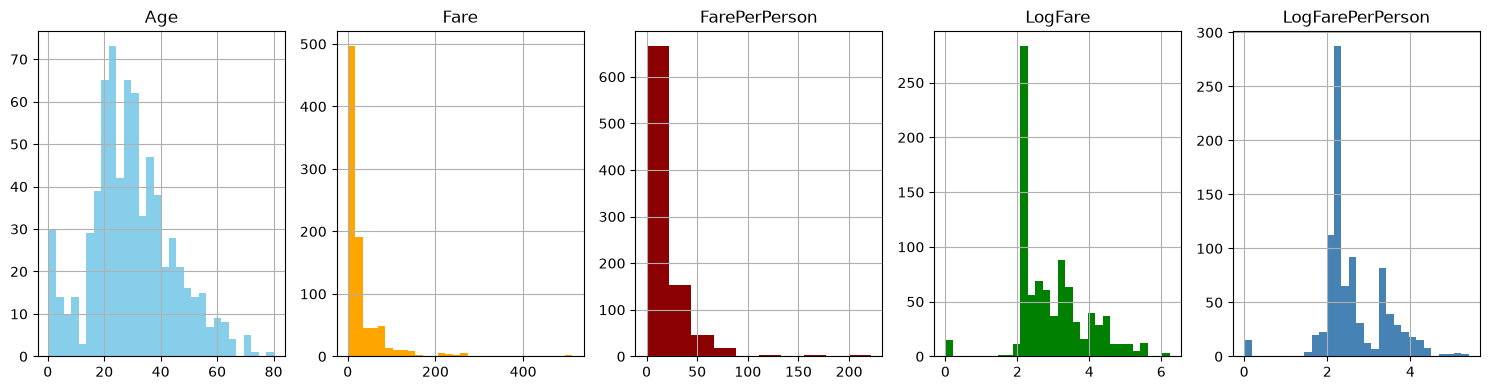

In [108]:
fig, axes = plt.subplots(1, 5, figsize = (15, 4))
df["Age"].hist(bins = 30, color = "skyblue", ax = axes[0])
axes[0].set_title("Age")
df["Fare"].hist(bins = 30, color = "orange", ax = axes[1])
axes[1].set_title("Fare")
df["FarePerPerson"].hist(bins = 10, color = "darkred", ax = axes[2])
axes[2].set_title("FarePerPerson")

# Taking the log of Fare and FarePerPerson
df["LogFare"] = np.log1p(df["Fare"])
df["LogFarePerPerson"] = np.log1p(df["FarePerPerson"])

df["LogFare"].hist(bins = 30, color = "green", ax = axes[3])
axes[3].set_title("LogFare")
df["LogFarePerPerson"].hist(bins = 30, color = "steelblue", ax = axes[4])
axes[4].set_title("LogFarePerPerson")

plt.tight_layout()
plt.show()

In [109]:
# Getting rid of redunant or intermediate features
df = df.drop(columns = ["Fare", "FarePerPerson", "Cabin", "RestOfName"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Surname,Title,FamilySize,IsAlone,Has_Cabin,Age_missing,LogFare,LogFarePerPerson
0,0,3,male,22.0,1,0,S,Braund,Mr,2,0,0,0,2.110213,2.110213
1,1,1,female,38.0,1,0,C,Cumings,Mrs,2,0,1,0,4.280593,4.280593
2,1,3,female,26.0,0,0,S,Heikkinen,Miss,1,1,0,0,2.188856,2.188856
3,1,1,female,35.0,1,0,S,Futrelle,Mrs,2,0,1,0,3.990834,3.316003
4,0,3,male,35.0,0,0,S,Allen,Mr,1,1,0,0,2.202765,2.202765
